[ask] [en] Last updated: 2026-09-04

**What it does**: Presents Qwen2.5-0.5B GSM8K question-only results for base, low-temperature, sequence-level power sampling, and repeated-sampling controls.

**What it saves**: none; all tables and figures are displayed from previously saved experiment artifacts.

**What it uses**: `../results/summary.json` and PNG files in `../figures/`, produced by `../analyze.py`.

# Reasoning with Sampling: small-scale result notebook

The central question is whether blockwise MCMC sampling from a distribution proportional to
$p(x)^\alpha$ improves a frozen 0.5B model—and whether it beats simpler ways to spend the same inference budget.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display

REPO = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "experiments" / "gsm8k_qwen05b" / "analyze.py").is_file()
)
ROOT = REPO / "experiments" / "gsm8k_qwen05b"
summary = json.loads((ROOT / "results" / "summary.json").read_text())
methods = ["Base, T=1", "Low temp, T=0.2", "Power, alpha=4", "Vote, 6 samples"]
for method in methods:
    row = summary[method]
    print(f"{method:22s} {100*row['mean_accuracy']:5.2f} ± {100*row['sd_accuracy']:.2f}%"
          f"   tokens={row['mean_sampled_tokens']:.0f}")

Base, T=1              12.03 ± 0.57%   tokens=272
Low temp, T=0.2        29.09 ± 1.40%   tokens=275
Power, alpha=4         32.95 ± 0.43%   tokens=1636
Vote, 6 samples        39.98 ± 1.21%   tokens=1638


## Formal three-seed comparison

Power sampling uses $\alpha=4$, proposal temperature 0.25, 32-token blocks, two MH updates per block,
and a 512-token response limit. Seeds are derived independently per question; bars show mean ± sample SD.

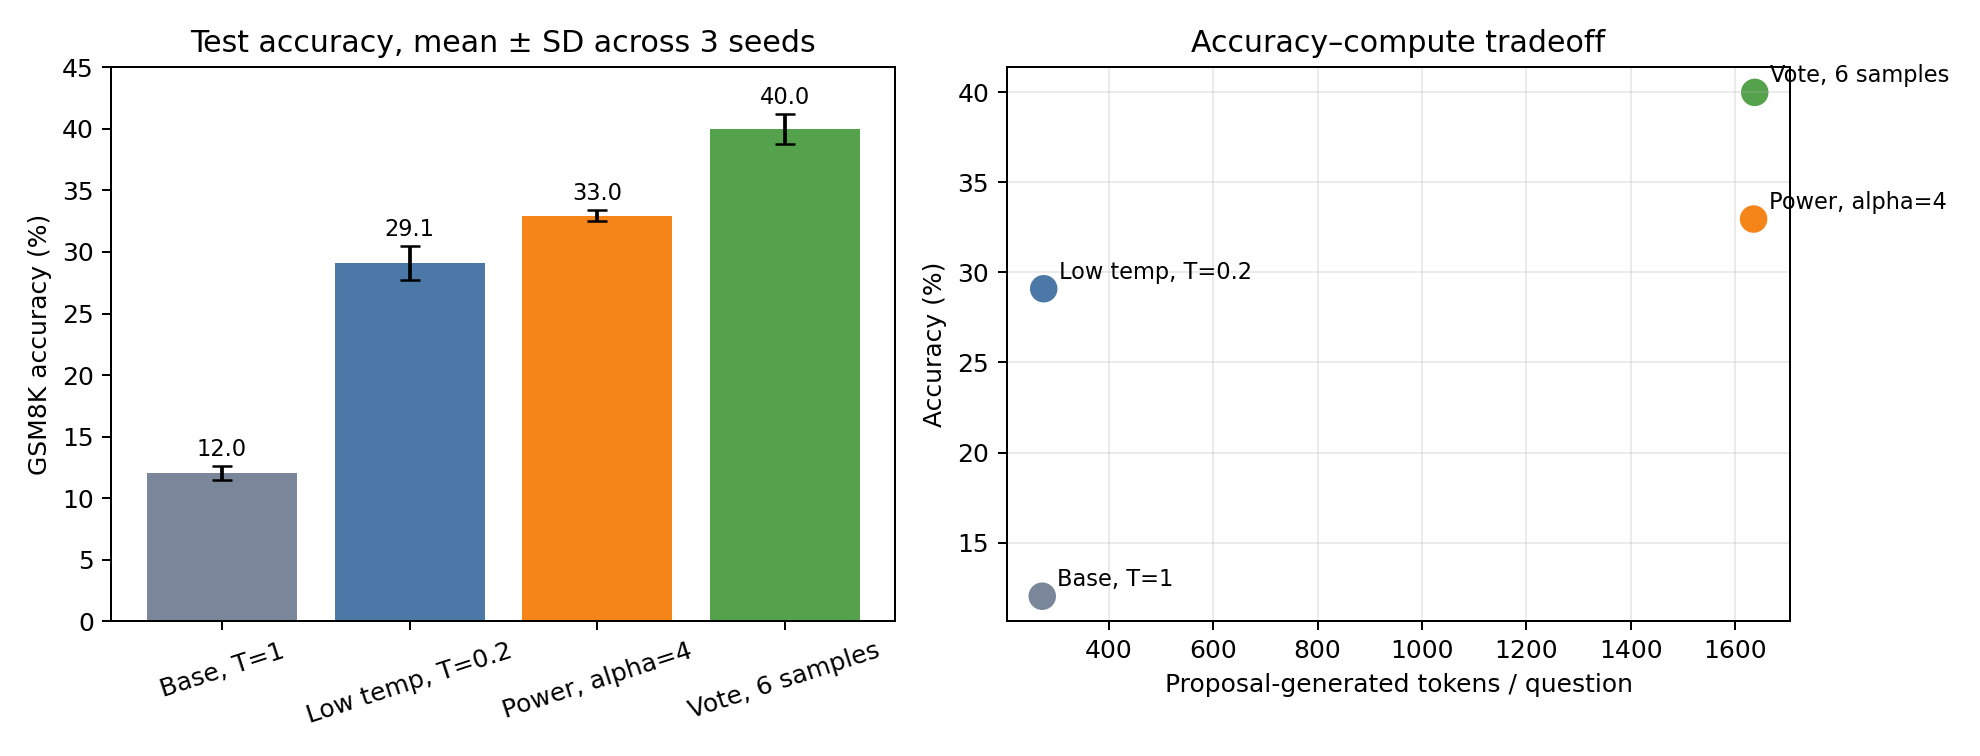

In [2]:
display(Image(filename=ROOT / 'figures' / 'main_results.png', width=1000))

Power improves over one selected low-temperature response by **3.87 percentage points**
(question-clustered 95% bootstrap CI **[2.40, 5.31]**). Six-sample voting improves over power by
**7.03 points** (**[5.48, 8.59]**) at nearly identical proposal-generated-token count.

## Development ablations

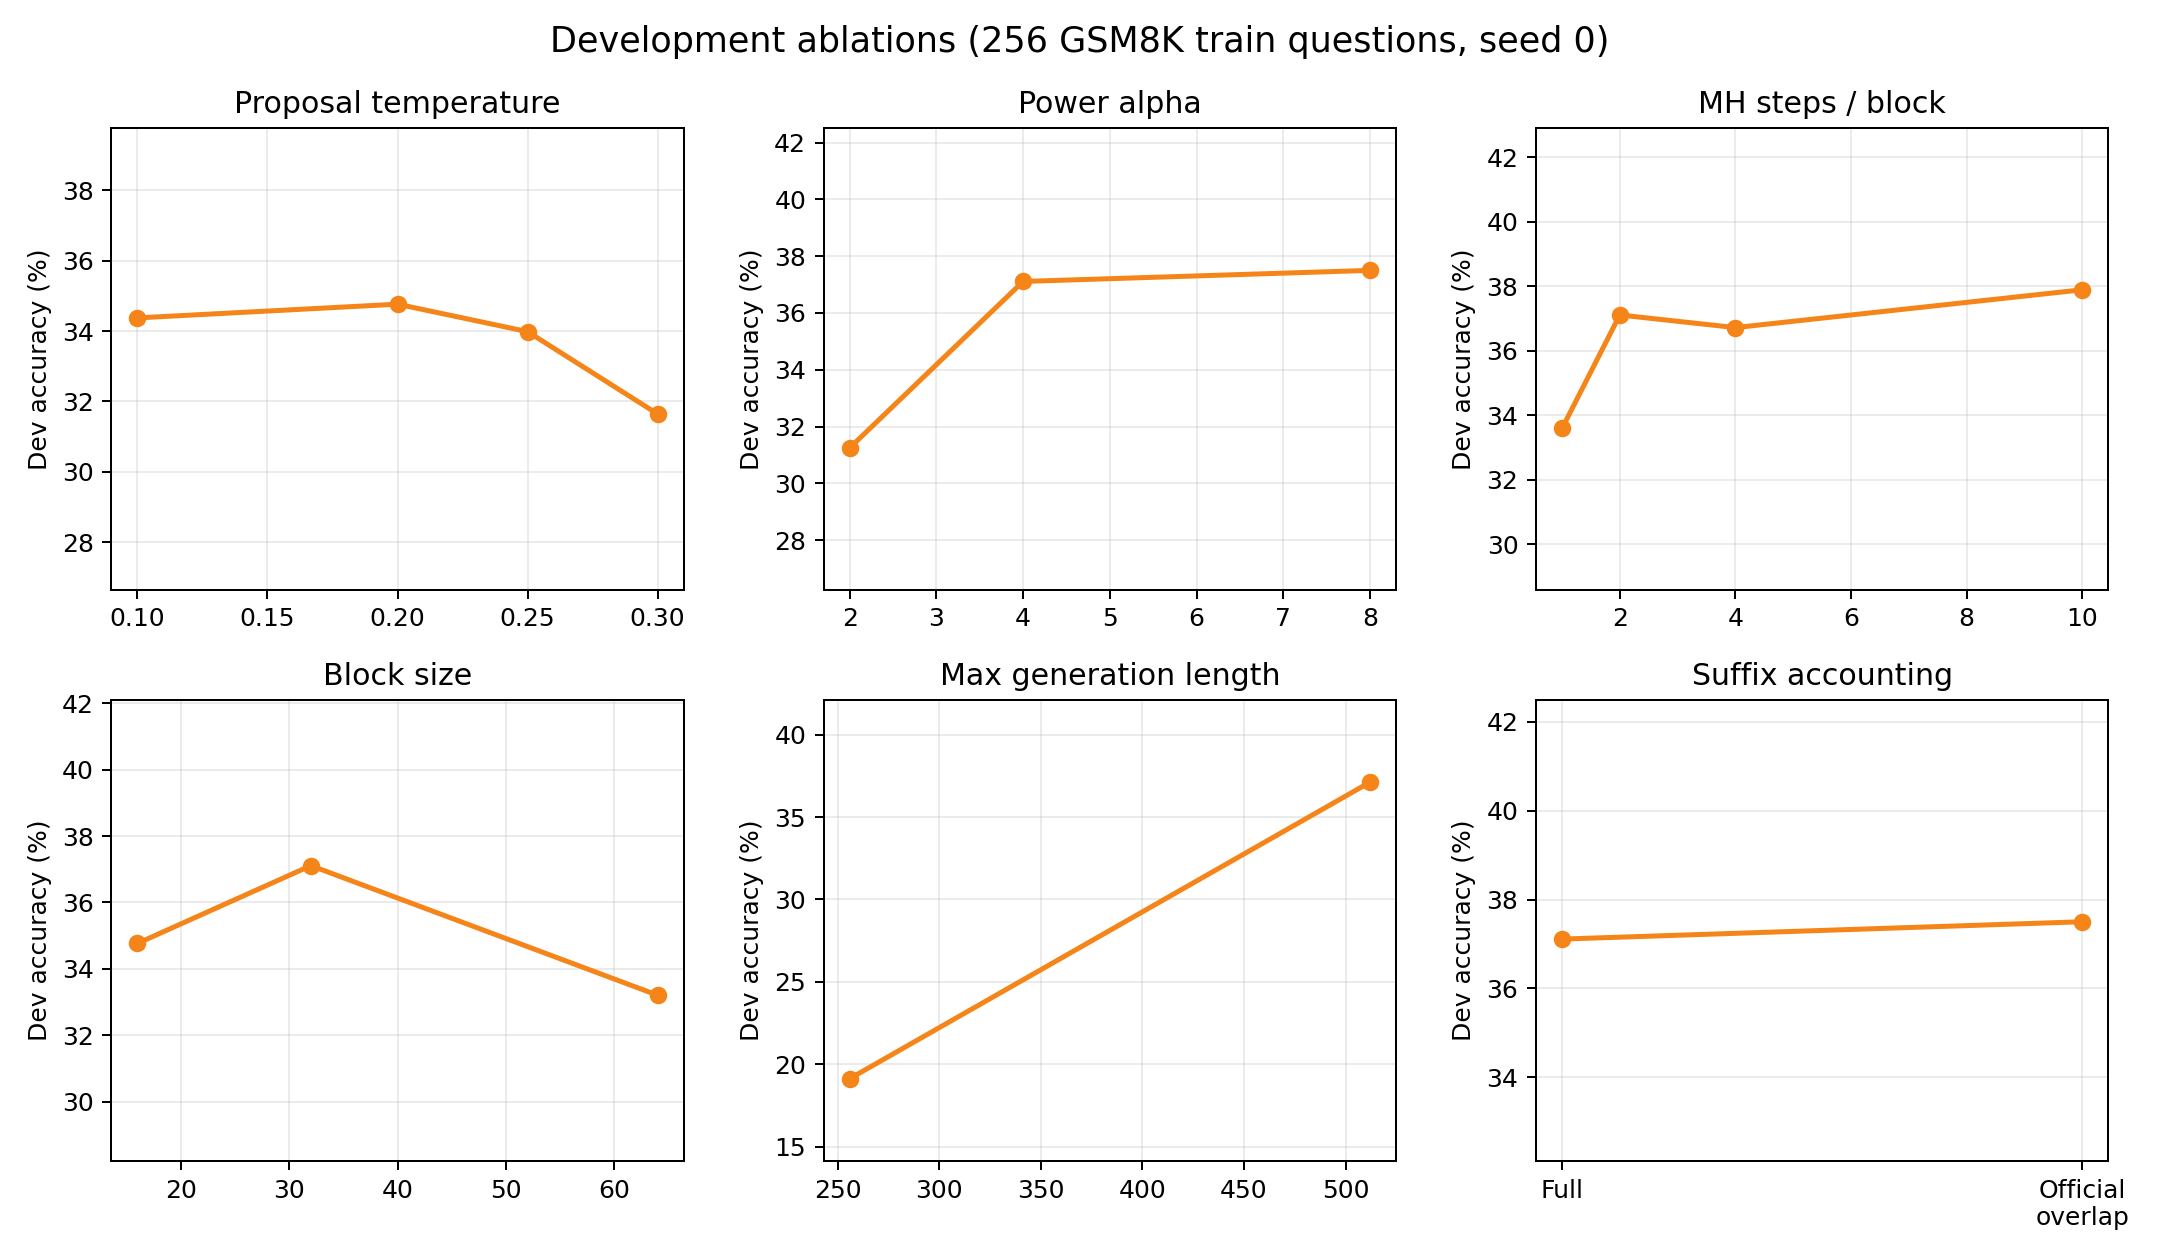

In [3]:
display(Image(filename=ROOT / 'figures' / 'ablations.png', width=1000))

The useful region is $\alpha\in[4,8]$, block size 32, and at least 512 output tokens. Ten MH steps—the
paper default—do not improve the full-test seed despite 3.7× the proposal-token cost of two steps.

## Repeated-sampling scaling and behavior

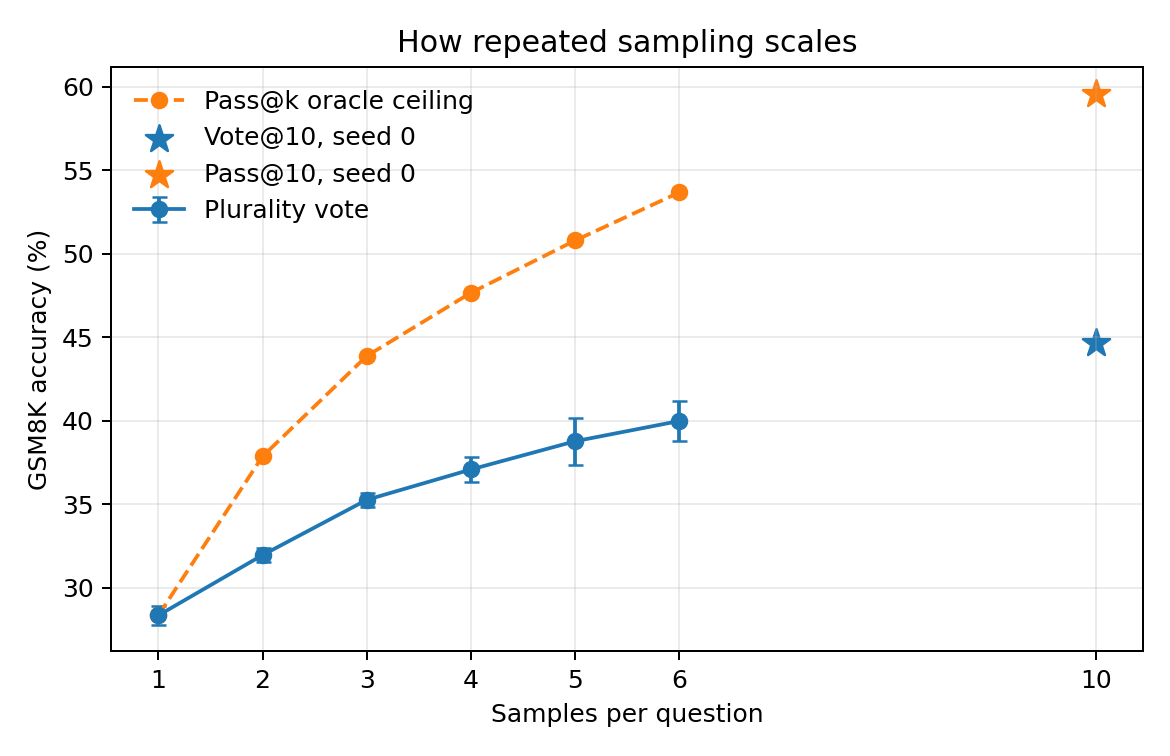

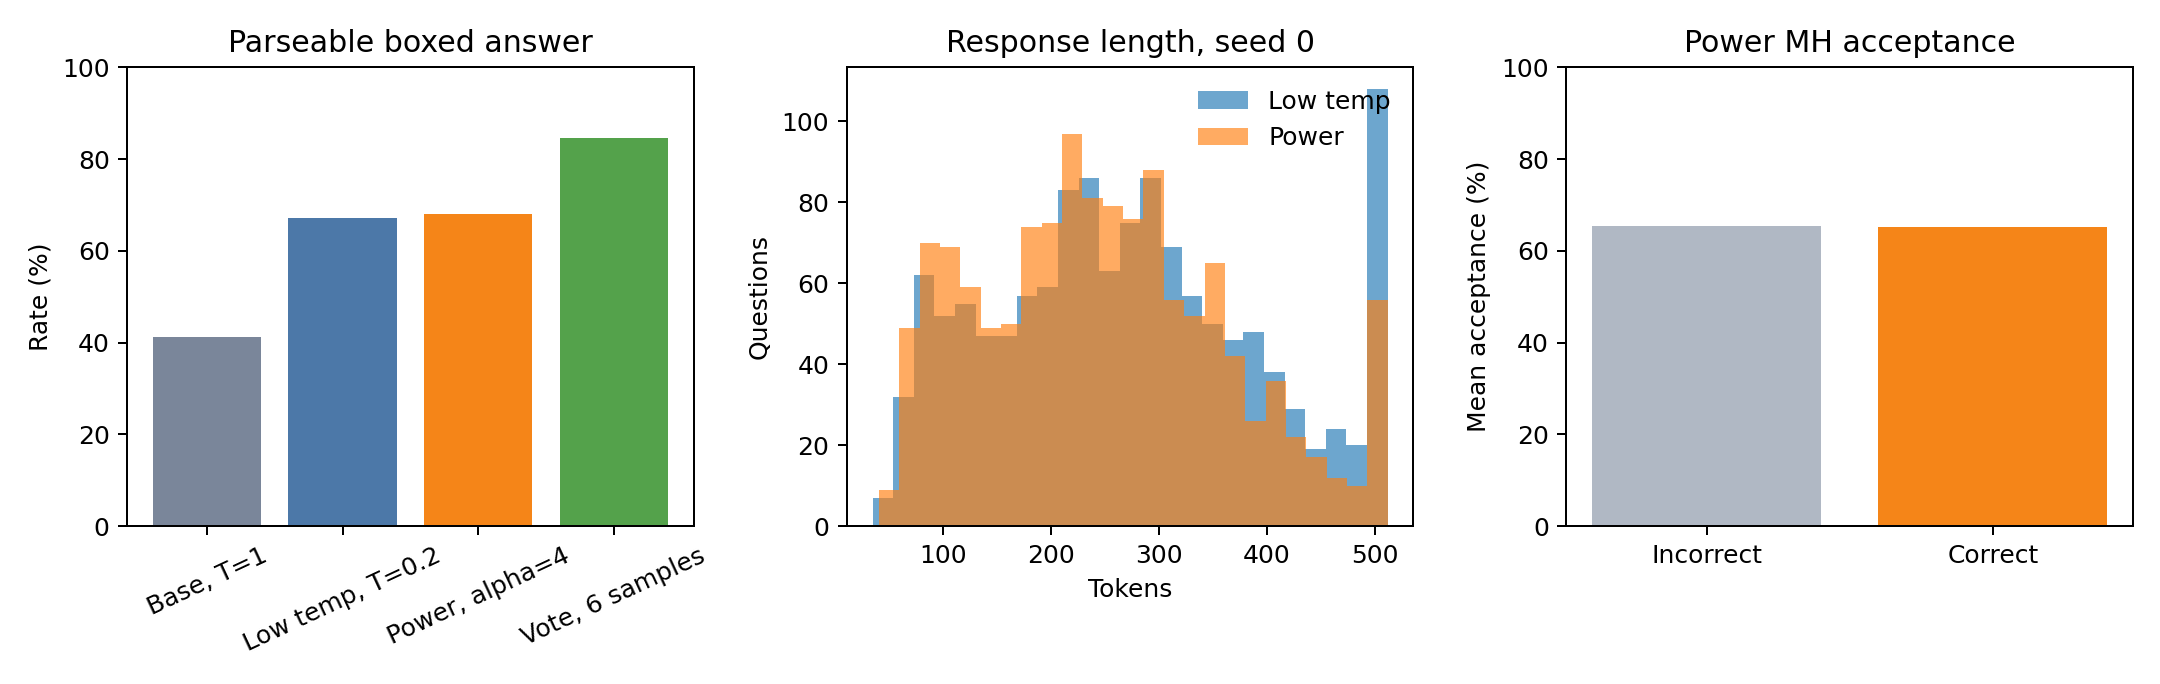

In [4]:
display(Image(filename=ROOT / "figures" / "vote_scaling.png", width=720))
display(Image(filename=ROOT / "figures" / "behavior.png", width=1000))

In [5]:
power_gain = summary["paired_differences"]["power_minus_low_temp"]
best = summary["exploratory"]
print("Power − low temp:", f"{100*power_gain['difference']:.2f} pp", power_gain['cluster_bootstrap_95_ci'])
print("Exploratory vote@10:", f"{100*best['vote10_seed0_accuracy']:.2f}%",
      f"pass@10={100*best['vote10_seed0_pass_at_10']:.2f}%")
print("Paper-default 10-step power:", f"{100*best['power10_seed0_accuracy']:.2f}%")

Power − low temp: 3.87 pp [0.024008086934546376, 0.05307050796057619]
Exploratory vote@10: 44.66% pass@10=59.59%
Paper-default 10-step power: 32.52%


## Takeaway

Sequence-level power sampling reliably exposes better responses than one low-temperature draw, but it is
not the best compute-aware method here. Six-sample voting reaches **39.98 ± 1.21%**, and exploratory
vote@10 reaches **44.66%** (one seed), whereas paper-default ten-step power reaches **32.52%**.

The result is limited to one small model, strict boxed-answer grading, and GSM8K. Proposal-token counts
also omit power sampling's additional likelihood-scoring passes.